In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

print("Contenu de Mon Drive :")
for item in MYDRIVE.iterdir():
    print("-", item.name)

Contenu de Mon Drive :
- Classroom
- Google AI Studio
- Colab Notebooks
- .ipynb_checkpoints
- PFA_


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

PREPROCESSED_DIR = Path("/content/drive/MyDrive/PFA_/preprocessed-multiclass")
RESULTS_DIR = Path("/content/drive/MyDrive/PFA_/results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Dossier utilisé :", PREPROCESSED_DIR)

# Vérifier les fichiers présents
print("\nFichiers dans le dossier :")
for file in PREPROCESSED_DIR.iterdir():
    print("-", file.name)

# Chemins des fichiers
x_train_path = PREPROCESSED_DIR / "X_train.csv"
x_test_path = PREPROCESSED_DIR / "X_test.csv"
y_train_path = PREPROCESSED_DIR / "y_train.csv"
y_test_path = PREPROCESSED_DIR / "y_test.csv"

# Chargement complet, sans échantillon
X_train = pd.read_csv(x_train_path, low_memory=False)
X_test = pd.read_csv(x_test_path, low_memory=False)
y_train = pd.read_csv(y_train_path, low_memory=False)
y_test = pd.read_csv(y_test_path, low_memory=False)

print("\nChargement terminé avec succès.")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Dossier utilisé : /content/drive/MyDrive/PFA_/preprocessed-multiclass

Fichiers dans le dossier :
- X_train.csv
- y_train.csv
- X_test.csv
- distribution_classes.png
- y_test.csv
- correlation_matrix_clean.png

Chargement terminé avec succès.
X_train : (2017889, 44)
X_test  : (504473, 44)
y_train : (2017889, 1)
y_test  : (504473, 1)


In [ ]:
# Nettoyer les noms des colonnes
X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()
y_train.columns = y_train.columns.str.strip()
y_test.columns = y_test.columns.str.strip()

# Supprimer les colonnes inutiles générées par pandas
for col in ["Unnamed: 0", "index"]:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])
    if col in y_train.columns:
        y_train = y_train.drop(columns=[col])
    if col in y_test.columns:
        y_test = y_test.drop(columns=[col])

# Transformer y_train et y_test en Series
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("Après nettoyage :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nClasses dans y_train :")
print(y_train.value_counts())

Après nettoyage :
X_train : (2017889, 44)
X_test  : (504473, 44)
y_train : (2017889,)
y_test  : (504473,)

Classes dans y_train :
Label
0     1677187
4      138279
2      102413
10      72655
3        8229
7        4746
6        4308
5        4182
11       2575
1        1562
12       1176
14        522
9          29
13         17
8           9
Name: count, dtype: int64


In [ ]:
# Remplacer les valeurs infinies
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Convertir en numérique
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Remplacer les valeurs manquantes par la médiane du train
medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# S'il reste des valeurs manquantes
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Vérifier que les colonnes train/test sont identiques
X_test = X_test[X_train.columns]

print("Nettoyage terminé.")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

Nettoyage terminé.
X_train : (2017889, 44)
X_test  : (504473, 44)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes détectées :")
for i, classe in enumerate(label_encoder.classes_):
    print(i, "=", classe)

Classes détectées :
0 = 0
1 = 1
2 = 2
3 = 3
4 = 4
5 = 5
6 = 6
7 = 7
8 = 8
9 = 9
10 = 10
11 = 11
12 = 12
13 = 13
14 = 14


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    verbose=1
)

rf_model.fit(X_train, y_train_encoded)

print("Entraînement Random Forest terminé sur tout X_train.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 30.3min


Entraînement Random Forest terminé sur tout X_train.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 30.8min finished


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1_macro = f1_score(y_test_encoded, y_pred, average="macro")
f1_weighted = f1_score(y_test_encoded, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("F1-score macro :", f1_macro)
print("F1-score weighted :", f1_weighted)

report = classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.2s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   15.5s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   15.7s finished


Accuracy : 0.9983507541533442
F1-score macro : 0.8694621516173539
F1-score weighted : 0.9983351208721543


,precision,recall,f1-score,support
0,0.999377,0.999015,0.999196,419297.000000
1,0.815303,0.790281,0.802597,391.000000
2,0.999883,0.999570,0.999727,25603.000000
3,0.996585,0.993194,0.994887,2057.000000
4,0.997481,0.996616,0.997048,34570.000000
5,0.952206,0.990440,0.970947,1046.000000
6,0.994424,0.993500,0.993962,1077.000000
7,1.000000,0.994945,0.997466,1187.000000
8,1.000000,1.000000,1.000000,2.000000
9,1.000000,0.571429,0.727273,7.000000


<Figure size 1400x1000 with 0 Axes>

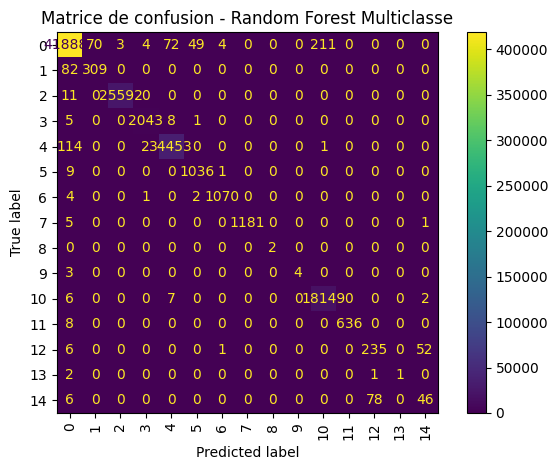

Image sauvegardée dans : /content/drive/MyDrive/PFA_/results/confusion_matrix_random_forest_multiclass.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(14, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("Matrice de confusion - Random Forest Multiclasse")
plt.tight_layout()

confusion_img_path = RESULTS_DIR / "confusion_matrix_random_forest_multiclass.png"
plt.savefig(confusion_img_path, dpi=300)

for i, classe in enumerate(label_encoder.classes_):
    print(i, "=", classe)

plt.show()

print("Image sauvegardée dans :", confusion_img_path)

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
36,Init_Win_bytes_backward,0.070030
28,Packet Length Mean,0.046956
24,Bwd Header Length,0.045757
6,Bwd Packet Length Max,0.043323
3,Fwd Packet Length Max,0.041948
25,Bwd Packets/s,0.041542
0,Flow Duration,0.037553
27,Max Packet Length,0.037343
38,min_seg_size_forward,0.036485
2,Total Length of Fwd Packets,0.034574


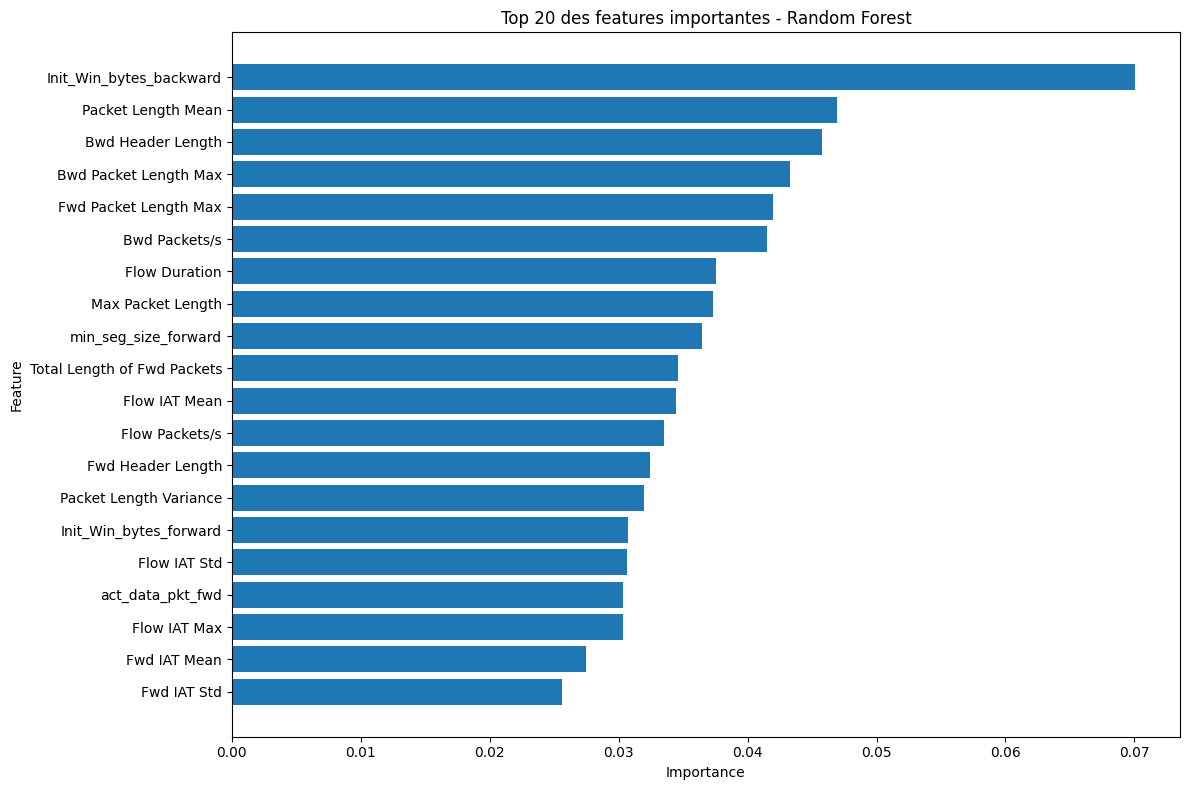

Image sauvegardée dans : /content/drive/MyDrive/PFA_/results/top_20_features_random_forest_multiclass.png


In [ ]:
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 des features importantes - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()

features_img_path = RESULTS_DIR / "top_20_features_random_forest_multiclass.png"
plt.savefig(features_img_path, dpi=300)

plt.show()

print("Image sauvegardée dans :", features_img_path)

In [ ]:
import joblib

# Rapport de classification
report_path = RESULTS_DIR / "classification_report_random_forest_multiclass.csv"
report_df.to_csv(report_path)

# Matrice de confusion CSV
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_path = RESULTS_DIR / "confusion_matrix_random_forest_multiclass.csv"
cm_df.to_csv(cm_path)

# Importance des features
features_csv_path = RESULTS_DIR / "feature_importance_random_forest_multiclass.csv"
feature_importance.to_csv(features_csv_path, index=False)

# Modèle Random Forest
model_path = RESULTS_DIR / "random_forest_multiclass_model.joblib"
joblib.dump(rf_model, model_path)

# Encodeur des labels
encoder_path = RESULTS_DIR / "label_encoder_random_forest_multiclass.joblib"
joblib.dump(label_encoder, encoder_path)

print("Tous les résultats sont sauvegardés dans :", RESULTS_DIR)
print("-", report_path.name)
print("-", cm_path.name)
print("-", features_csv_path.name)
print("-", model_path.name)
print("-", encoder_path.name)

Tous les résultats sont sauvegardés dans : /content/drive/MyDrive/PFA_/results
- classification_report_random_forest_multiclass.csv
- confusion_matrix_random_forest_multiclass.csv
- feature_importance_random_forest_multiclass.csv
- random_forest_multiclass_model.joblib
- label_encoder_random_forest_multiclass.joblib



# Documentation - Random Forest Multiclasse IDS

## Projet
Système de Détection d'Intrusions Réseau basé sur Machine Learning.

## Dataset
CIC-IDS2017.

## Dossier utilisé
preprocessed-multiclass.

## Fichiers utilisés
- X_train.csv
- X_test.csv
- y_train.csv
- y_test.csv

## Type de classification
Classification multiclasse.

## Modèle utilisé
Random Forest Classifier.

## Objectif
Le but est de détecter le type de trafic réseau :
- trafic normal
- attaques DDoS
- attaques DoS
- PortScan
- Bot
- Web Attack
- autres classes présentes dans le dataset

## Méthode
Les données étaient déjà prétraitées et divisées en train/test.
Nous avons utilisé X_train et y_train pour entraîner le modèle.
Nous avons utilisé X_test et y_test pour évaluer le modèle.

## Dimensions des données
X_train : {X_train.shape}
X_test : {X_test.shape}

## Nombre de features
{X_train.shape[1]}

## Classes détectées
{list(label_encoder.classes_)}

## Résultats obtenus
Accuracy : {accuracy}
F1-score macro : {f1_macro}
F1-score weighted : {f1_weighted}

## Fichiers générés
- classification_report_random_forest_multiclass.csv
- confusion_matrix_random_forest_multiclass.csv
- confusion_matrix_random_forest_multiclass.png
- feature_importance_random_forest_multiclass.csv
- top_20_features_random_forest_multiclass.png
- random_forest_multiclass_model.joblib
- label_encoder_random_forest_multiclass.joblib

## Interprétation
Le modèle Random Forest apprend à classer chaque flux réseau dans sa classe correspondante.
La matrice de confusion permet de voir les classes bien détectées et les classes confondues.
Le classification report donne la précision, le rappel et le F1-score pour chaque type d'attaque.
L'importance des features permet d'identifier les variables réseau les plus utiles pour la détection d'intrusion.
"""

doc_path = RESULTS_DIR / "README_random_forest_multiclass.md"

with open(doc_path, "w", encoding="utf-8") as f:
    f.write(documentation)

print("Documentation sauvegardée dans :", doc_path)       
                  


